# Supplementary Figure S5: `s05_layer_selection`

**Per-channel encoding-layer selection.** We fit encoding models using cross-validated ridge regression for each of the $250$ model-site pairs. In each case, the best-predicting backbone layer was chosen per channel via held-out validation $R^2$. Site markers are colored by recorded region (aIT, cIT, V3/V4, STS); models comprise $10$ networks spanning three trained-model families and an Untrained baseline. (A) Validation $R^2$ versus relative layer depth for each model (one panel per model, one line per site, $n = 25$ sites), with the selected peak block marked. Curves generally rise then plateau, with peaks concentrated at intermediate-to-late depths. (B) Selected relative depth per model (swarm of $n = 25$ sites, colored by region; black-over-color bar = per-model median). (C) Read-out depth summary: per-model mean selected relative depth (dot) with min-max range (line), sorted by mean. (D) Mean selected depth per recorded visual area (V3, V4, cIT, aIT, STS), one line per model (colored) plus grand mean (black); ventral areas shaded. Read-out depth is generally greater for more anterior ventral stream areas. (E) Per-model Spearman rank correlation between selected depth and coarse ventral area rank (V3 $<$ V4 $<$ cIT $<$ aIT), sorted; bars colored by model, with significance stars (*** $p < 10^{-3}$, ** $p < 10^{-2}$, * $p < 0.05$, n.s. otherwise). (F) Same as (E), but over a finer ventral-stream ordering, with monkey V's $5$ sites resolved by their location along the Neuropixels probe. Adversarially trained models are shown in bold.

Rendered by `figures/supplementary/sup_layer_selection.py`; the PNG written below is pixel-identical to the manuscript file `s05_layer_selection.png` in the reference environment (see docs/REPRODUCIBILITY.md). The preview shown here is downscaled.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
out_dir = paths.output_dir() / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
from figures.supplementary.sup_layer_selection import main

# main() writes <out_dir>/<manuscript name>.png (border-trimmed, so it matches the submitted file)
# and returns its path; keyword arguments select the non-default variants documented in the script.
png = main(str(out_dir))
print(png)

Saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s05_layer_selection.png

Table 3 reproduction (sorted by mean depth):
  SigLIP2      mean=0.55  range 0.17-0.92  n=25
  CLIPAG       mean=0.57  range 0.27-0.82  n=25
  DINOv2       mean=0.60  range 0.27-1.00  n=25
  RADIO        mean=0.67  range 0.18-1.00  n=25
  RegNetY      mean=0.70  range 0.37-1.00  n=25
  Untrained    mean=0.70  range 0.18-1.00  n=25
  ResNet50     mean=0.73  range 0.47-1.00  n=25
  RN50-CLIP    mean=0.74  range 0.27-1.00  n=25
  RN50-DINO    mean=0.84  range 0.60-1.00  n=25
  RN50-Robust  mean=0.87  range 0.53-1.00  n=25

Hierarchical correspondence (per-model Spearman):
  Untrained    area rho=+0.04 n.s.  site rho=+0.04 n.s.
  SigLIP2      area rho=+0.61    *  site rho=+0.61    *
  RN50-CLIP    area rho=+0.34 n.s.  site rho=+0.34 n.s.
  RegNetY      area rho=+0.68   **  site

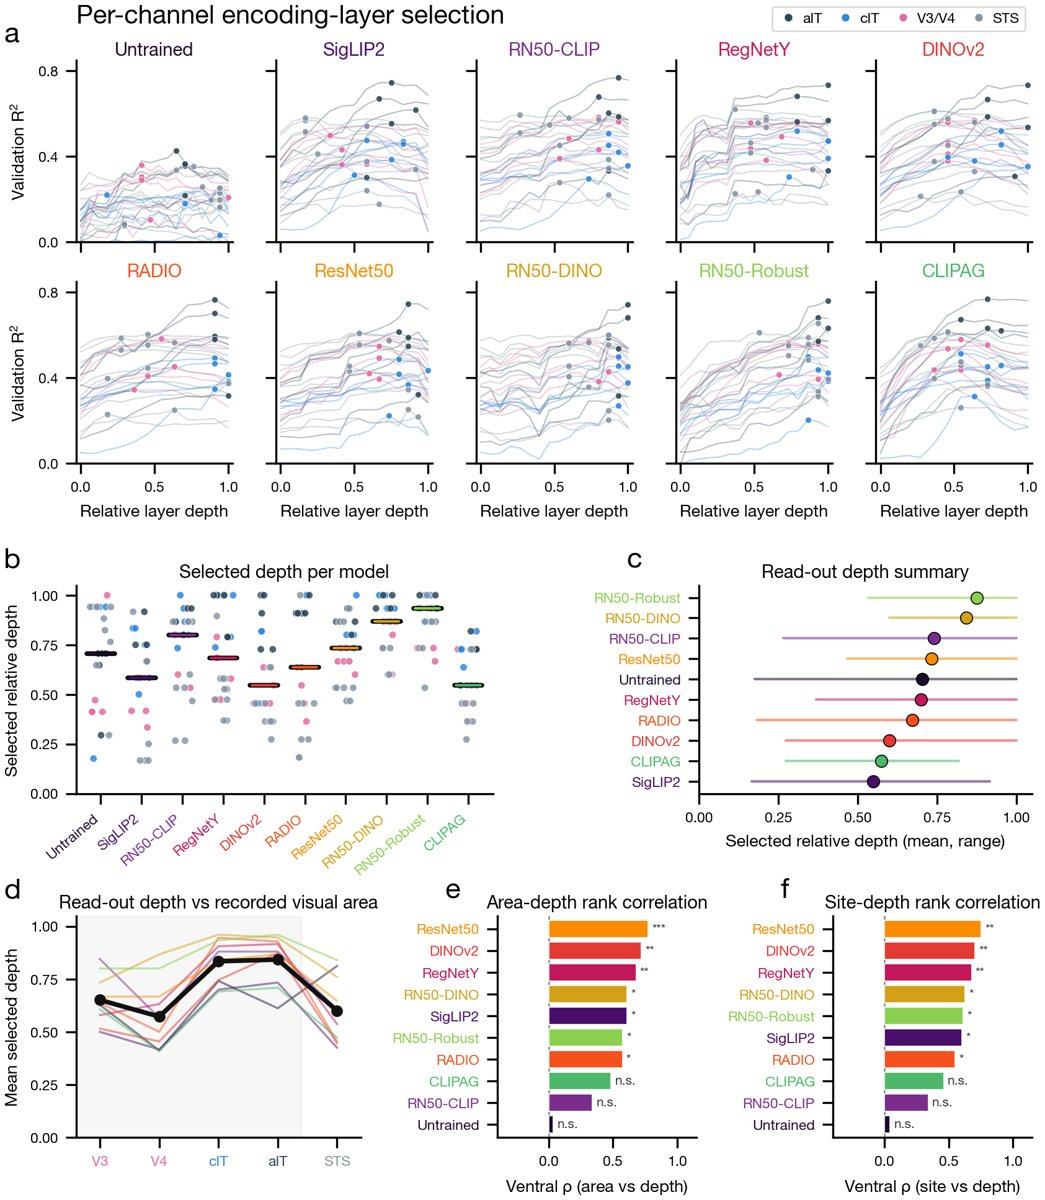

In [3]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# Show a downscaled JPEG preview (the full-resolution PNG can be tens of MB); open the file for detail.
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))